# Iris Flower Classification

## Oasis Infobyte Data Science Internship — Task 1

### Project Objective

Build a machine learning classification model to predict the species of an
Iris flower using its sepal and petal measurements.

### Dataset

The Iris dataset is loaded directly using `sklearn.datasets.load_iris()`.

### Machine Learning Workflow

1. Import libraries
2. Load the Iris dataset
3. Understand the dataset
4. Perform Exploratory Data Analysis (EDA)
5. Discuss feature selection
6. Split the data into training and testing sets
7. Train classification models
8. Evaluate model performance
9. Compare models
10. Select the best-performing model
11. Draw conclusions

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

In [10]:
iris=load_iris()
print(type(iris))

<class 'sklearn.utils._bunch.Bunch'>


In [11]:
print(iris.keys())

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


In [12]:
print(iris.data[:5])

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]


In [13]:
print(iris.target[:10])

[0 0 0 0 0 0 0 0 0 0]


In [14]:
print(iris.target_names)

['setosa' 'versicolor' 'virginica']


In [15]:
print(iris.data.shape)

(150, 4)


In [16]:
df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df['species'] = iris.target

df['species'] = df['species'].map(
    {
        0: 'setosa',
        1: 'versicolor',
        2: 'virginica'
    }
)

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [17]:
df.shape

(150, 5)

In [18]:
df.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

In [19]:
df.dtypes

sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species                  str
dtype: object

In [20]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [21]:
df['species'].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

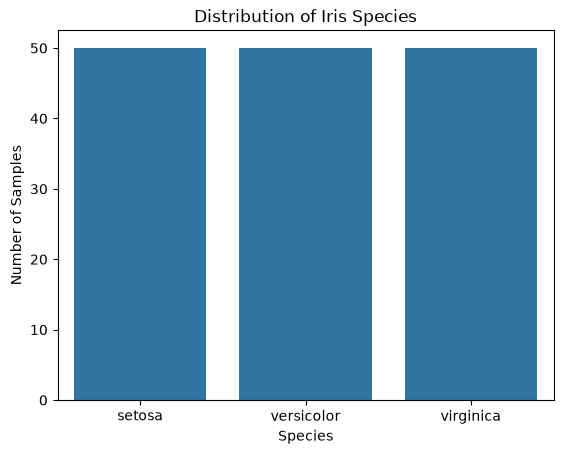

In [22]:
sns.countplot(data=df, x='species')

plt.title('Distribution of Iris Species')
plt.xlabel('Species')
plt.ylabel('Number of Samples')

plt.show()

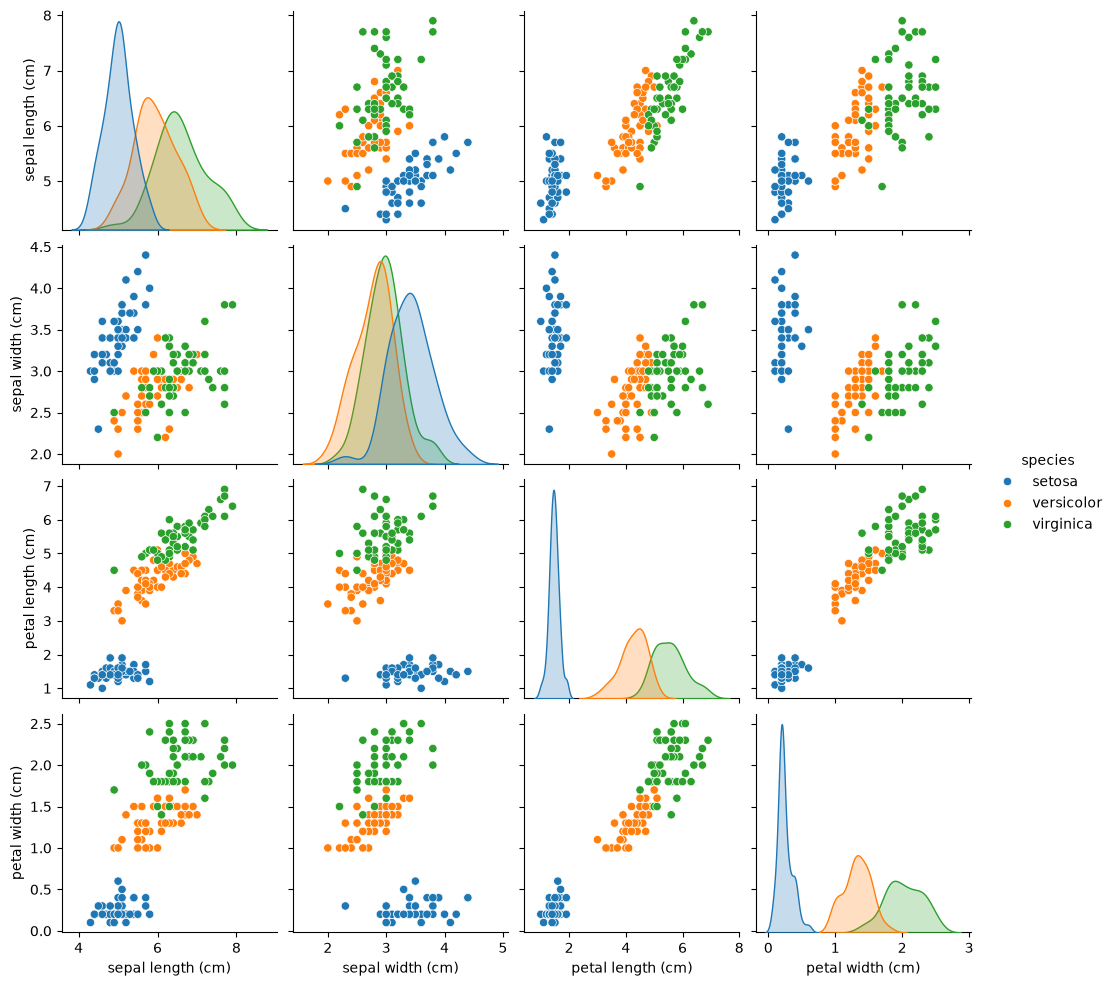

In [23]:
sns.pairplot(
    df,
    hue='species'
)

plt.show()

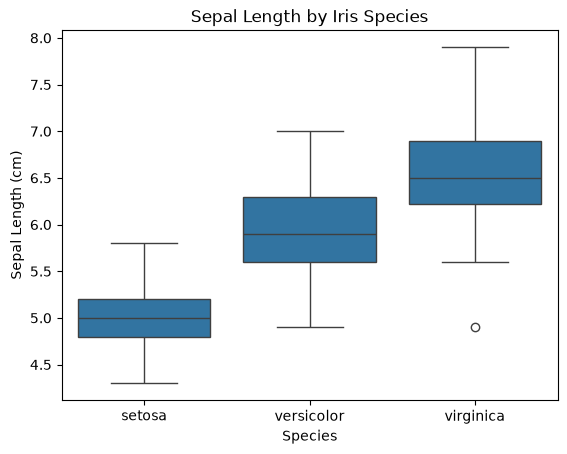

In [24]:
sns.boxplot(
    data=df,
    x='species',
    y='sepal length (cm)'
)

plt.title('Sepal Length by Iris Species')
plt.xlabel('Species')
plt.ylabel('Sepal Length (cm)')

plt.show()

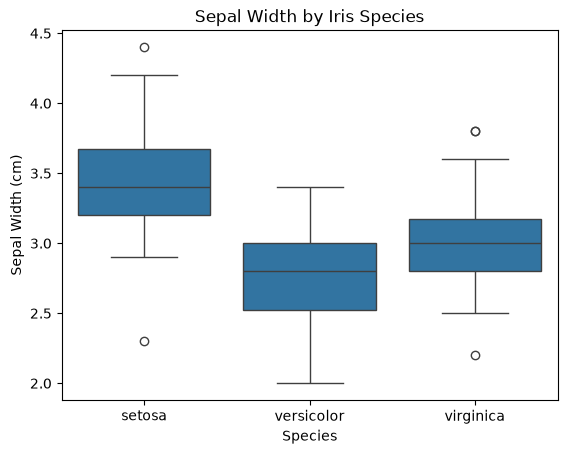

In [25]:
sns.boxplot(
    data=df,
    x='species',
    y='sepal width (cm)'
)

plt.title('Sepal Width by Iris Species')
plt.xlabel('Species')
plt.ylabel('Sepal Width (cm)')

plt.show()

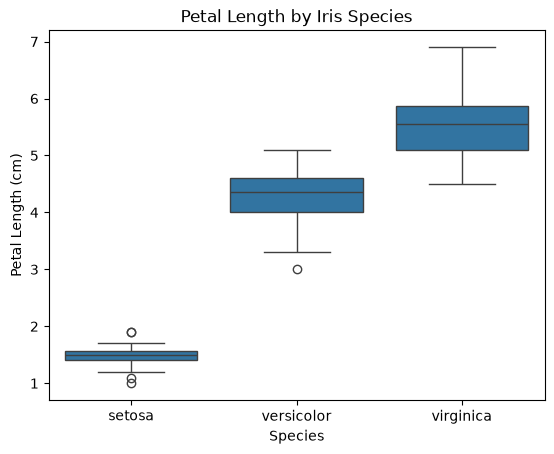

In [26]:
sns.boxplot(
    data=df,
    x='species',
    y='petal length (cm)'
)

plt.title('Petal Length by Iris Species')
plt.xlabel('Species')
plt.ylabel('Petal Length (cm)')

plt.show()

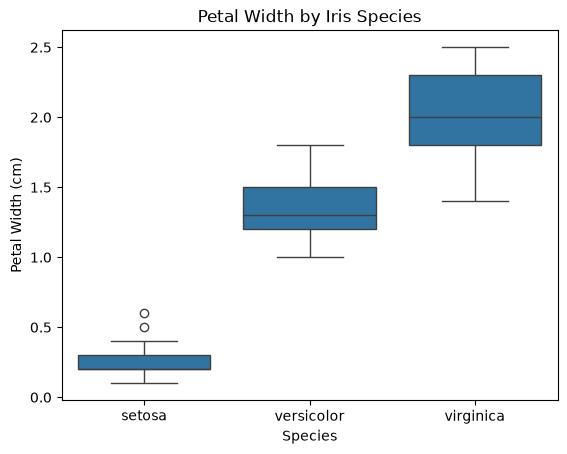

In [27]:
sns.boxplot(
    data=df,
    x='species',
    y='petal width (cm)'
)

plt.title('Petal Width by Iris Species')
plt.xlabel('Species')
plt.ylabel('Petal Width (cm)')

plt.show()

In [28]:
X = df.drop('species', axis=1)

In [29]:
y = df['species']

In [30]:
print(X.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


In [31]:
print(y.head())

0    setosa
1    setosa
2    setosa
3    setosa
4    setosa
Name: species, dtype: str


In [32]:
from sklearn.model_selection import train_test_split

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [34]:
print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training targets:", y_train.shape)
print("Testing targets:", y_test.shape)

Training features: (120, 4)
Testing features: (30, 4)
Training targets: (120,)
Testing targets: (30,)


In [35]:
from sklearn.tree import DecisionTreeClassifier

In [36]:
model_dt = DecisionTreeClassifier(random_state=42)

model_dt.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [37]:
y_pred_dt = model_dt.predict(X_test)

In [38]:
from sklearn.metrics import accuracy_score

In [39]:
accuracy_dt = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", accuracy_dt)

Decision Tree Accuracy: 1.0


In [40]:
from sklearn.metrics import confusion_matrix

In [41]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

print(cm_dt)

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


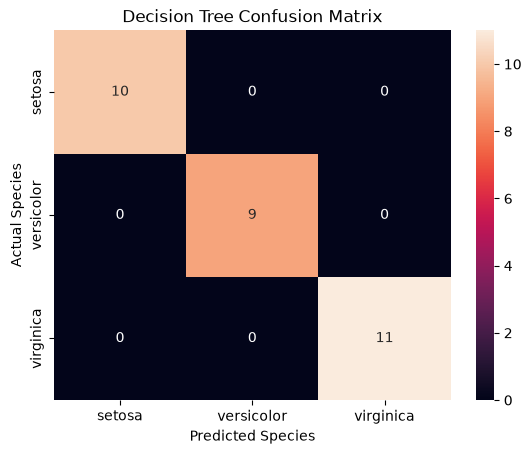

In [42]:
sns.heatmap(
    cm_dt,
    annot=True,
    fmt='d',
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.title('Decision Tree Confusion Matrix')
plt.xlabel('Predicted Species')
plt.ylabel('Actual Species')

plt.show()

In [43]:
from sklearn.metrics import classification_report

In [44]:
report_dt = classification_report(y_test, y_pred_dt)
print(report_dt)

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [45]:
from sklearn.linear_model import LogisticRegression

In [46]:
model_lr = LogisticRegression(max_iter=200, random_state=42)

model_lr.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",200
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbf

In [47]:
y_pred_lr = model_lr.predict(X_test)

In [48]:
accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", accuracy_lr)

Logistic Regression Accuracy: 1.0


In [49]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

print(cm_lr)

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


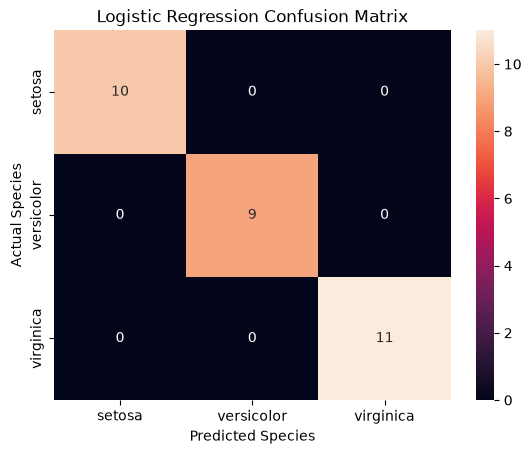

In [50]:
sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted Species')
plt.ylabel('Actual Species')

plt.show()

In [51]:
report_lr = classification_report(y_test, y_pred_lr)

print(report_lr)

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [52]:
model_comparison = pd.DataFrame({
    'Model': ['Decision Tree', 'Logistic Regression'],
    'Accuracy': [accuracy_dt, accuracy_lr]
})

model_comparison

,Model,Accuracy
0,Decision Tree,1.0
1,Logistic Regression,1.0


In [53]:
best_model = model_comparison.loc[
    model_comparison['Accuracy'].idxmax()
]

print("Best Model:", best_model['Model'])
print("Best Accuracy:", best_model['Accuracy'])

Best Model: Decision Tree
Best Accuracy: 1.0


In [54]:
print("===== Decision Tree =====")
print(report_dt)

print("\n===== Logistic Regression =====")
print(report_lr)

===== Decision Tree =====
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


===== Logistic Regression =====
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [55]:
print("Decision Tree Confusion Matrix:")
print(cm_dt)

print("\nLogistic Regression Confusion Matrix:")
print(cm_lr)

Decision Tree Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Logistic Regression Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [56]:
performance_summary = pd.DataFrame({
    'Model': ['Decision Tree', 'Logistic Regression'],
    'Accuracy': [accuracy_dt, accuracy_lr]
})

performance_summary

,Model,Accuracy
0,Decision Tree,1.0
1,Logistic Regression,1.0


In [57]:
best_model_name = performance_summary.loc[
    performance_summary['Accuracy'].idxmax(),
    'Model'
]

best_accuracy = performance_summary['Accuracy'].max()

print("Best Model:", best_model_name)
print("Best Accuracy:", best_accuracy)

Best Model: Decision Tree
Best Accuracy: 1.0


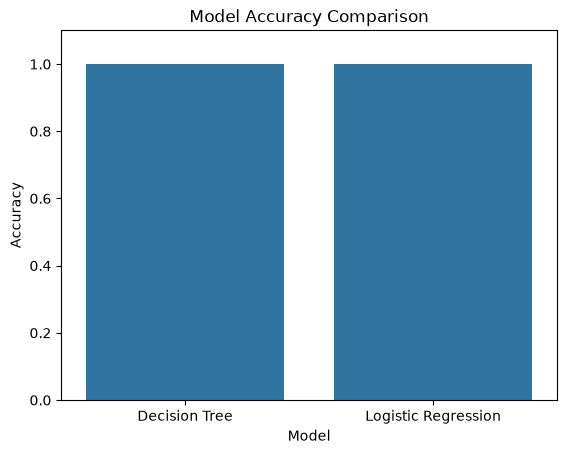

In [58]:
sns.barplot(
    data=performance_summary,
    x='Model',
    y='Accuracy'
)

plt.title('Model Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0, 1.1)

plt.show()

In [59]:
print(f"The best-performing model is {best_model_name} with an accuracy of {best_accuracy:.2%}.")

The best-performing model is Decision Tree with an accuracy of 100.00%.


## Conclusion

The Iris Flower Classification project successfully demonstrated a complete
machine learning classification workflow.

The Iris dataset was explored using descriptive statistics, species
distribution analysis, pairplots, and box plots. The exploratory analysis
showed that petal length and petal width provide stronger separation between
the Iris species compared with the sepal measurements.

Two classification algorithms were trained and evaluated:

- Decision Tree Classifier
- Logistic Regression

The models were evaluated using accuracy, confusion matrices, and
classification reports containing precision, recall, and F1-score.

Based on the test-set results, the model with the highest accuracy was
selected as the best-performing model for this project.

The project demonstrates the complete workflow from data understanding and
exploratory data analysis to model training, evaluation, and model comparison.